# Preparation

Split the data into two, one for the training (more precisely for training/dev/test)
and the other for a simple validation (to mimic prod env)

In [35]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Flatten, GlobalMaxPooling1D, Embedding, Conv1D, LSTM, Activation, Dropout, Dense

In [4]:
df = pd.read_csv('../data/raw/IMDB Dataset.csv')

first_part = df.iloc[:100]
second_part = df.iloc[100:]

first_part.to_csv('../data/raw/dataset-unseen.csv', index=False)
second_part.to_csv('../data/raw/dataset-training.csv', index=False)

print(f"Done! Saved {len(first_part)} rows to part 1 and {len(second_part)} rows to part 2.")

Done! Saved 100 rows to part 1 and 49900 rows to part 2.


# EDA and cleaning

In [5]:
movie_reviews = pd.read_csv('../data/raw/dataset-training.csv')

In [8]:
movie_reviews.shape

(49900, 2)

In [9]:
movie_reviews.head(5)

,review,sentiment
0,This short film that inspired the soon-to-be f...,positive
1,"Okay, last night, August 18th, 2004, I had the...",negative
2,I bought this game on an impulse buy from walm...,positive
3,"No, this hilariously horrible 70's made-for-TV...",positive
4,It is easy to tell early in this movie exactly...,negative


In [10]:
# Checking for missing values

movie_reviews.isnull().values.any()

np.False_

<Axes: xlabel='sentiment', ylabel='count'>

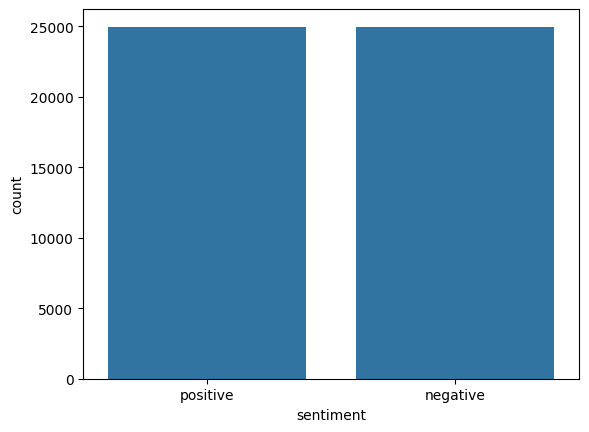

In [ ]:
# Checking the distribution of positive/negative sentiments in the dataset
import seaborn as sns

sns.countplot(x='sentiment', data=movie_reviews)

## Cleanup data

In [12]:
movie_reviews["review"][2]

"I bought this game on an impulse buy from walmart. I am glad I did. It was very entertaining listening to Sean Connery and playing the game. I thought the graphics were the best I have ever seen in a movie/game remake. The bonus levels were very hard! The sniper one I think was too hard, it made me so frustrated I didn't play the game for a week and a half. There were too many people shooting at you with nothing to hide behind or life to handle it. <br /><br />The only thing I might change was the upgrade system. I didn't notice any difference from un-upgraded equipment to the upgraded, such as buying an armor upgrade didn't seem to make the armor stronger or more filling on my life meter. I really liked the Q copter. I think the developers did a good job."

In [16]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    '''Removes HTML tags'''
    return TAG_RE.sub('', text)


In [17]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\andry\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [18]:
# TODO: improve this
def preprocess_text(sen):
    '''Cleans text data up, leaving only 2 or more char long non-stepwords composed of A-Z & a-z only
    in lowercase'''
    
    sentence = sen.lower()

    # Remove html tags
    sentence = remove_tags(sentence)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)  # When we remove apostrophe from the word "Mark's", the apostrophe is replaced by an empty space. Hence, we are left with single character "s" that we are removing here.

    # Remove multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)  # Next, we remove all the single characters and replace it by a space which creates multiple spaces in our text. Finally, we remove the multiple spaces from our text as well.

    # Remove Stopwords
    pattern = re.compile(r'\b(' + r'|'.join(stopwords.words('english')) + r')\b\s*')
    sentence = pattern.sub('', sentence)

    return sentence

In [ ]:
# Calling preprocessing_text function on movie_reviews

X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

In [20]:
# Sample cleaned up movie review 

X[2]

'bought game impulse buy walmart glad entertaining listening sean connery playing game thought graphics best ever seen movie game remake bonus levels hard sniper one think hard made frustrated play game week half many people shooting nothing hide behind life handle thing might change upgrade system notice difference un upgraded equipment upgraded buying armor upgrade seem make armor stronger filling life meter really liked copter think developers good job '

In [22]:
# Converting sentiment labels to 0 & 1

y = movie_reviews['sentiment']

y = np.array(list(map(lambda x: 1 if x=="positive" else 0, y)))

In [24]:
# TODO: split into train, dev and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Preparing embedding layer
Let's now write the script for our embedding layer. Embedding layer converts our textual data into numeric form. It is then used as the first layer for the deep learning models in Keras.

In [26]:
# Embedding layer expects the words to be in numeric form 
# Using Tokenizer function from keras.preprocessing.text library
# Method fit_on_text trains the tokenizer 
# Method texts_to_sequences converts sentences to their numeric form

word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)

X_train = word_tokenizer.texts_to_sequences(X_train)
X_test = word_tokenizer.texts_to_sequences(X_test)

In [27]:
# Adding 1 to store dimensions for words for which no pretrained word embeddings exist

vocab_length = len(word_tokenizer.word_index) + 1

vocab_length

91927

In [29]:
# Padding all reviews to fixed length 100
maxlen = 100

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)

In [31]:
# Load GloVe word embeddings and create an Embeddings Dictionary

from numpy import asarray
from numpy import zeros

embeddings_dictionary = dict()
glove_file = open('../data/raw/glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [32]:
# Create Embedding Matrix having 100 columns 
# Containing 100-dimensional GloVe word embeddings for all words in our corpus.

embedding_matrix = zeros((vocab_length, 100))
for word, index in word_tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [33]:
embedding_matrix.shape

(91927, 100)

# LSTM

In [36]:
# Neural Network architecture

lstm_model = Sequential()
embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], trainable=False)

lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128))

lstm_model.add(Dense(1, activation='sigmoid'))

In [37]:
# Model compiling

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(lstm_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,192,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,192,700 (35.07 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,192,700 (35.07 MB)

None


In [38]:
# Model Training

lstm_model_history = lstm_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - acc: 0.7493 - loss: 0.5166 - val_acc: 0.8015 - val_loss: 0.4358
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 148ms/step - acc: 0.8124 - loss: 0.4205 - val_acc: 0.8257 - val_loss: 0.3968
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - acc: 0.8374 - loss: 0.3729 - val_acc: 0.8257 - val_loss: 0.4009
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 161ms/step - acc: 0.8516 - loss: 0.3464 - val_acc: 0.8474 - val_loss: 0.3430
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 189ms/step - acc: 0.8655 - loss: 0.3204 - val_acc: 0.8575 - val_loss: 0.3361
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 187ms/step - acc: 0.8771 - loss: 0.2960 - val_acc: 0.8620 - val_loss: 0.3248


In [39]:
score = lstm_model.evaluate(X_test, y_test, verbose=1)

312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - acc: 0.8670 - loss: 0.3171


In [40]:
# Model Performance

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.3170661926269531
Test Accuracy: 0.8670340776443481


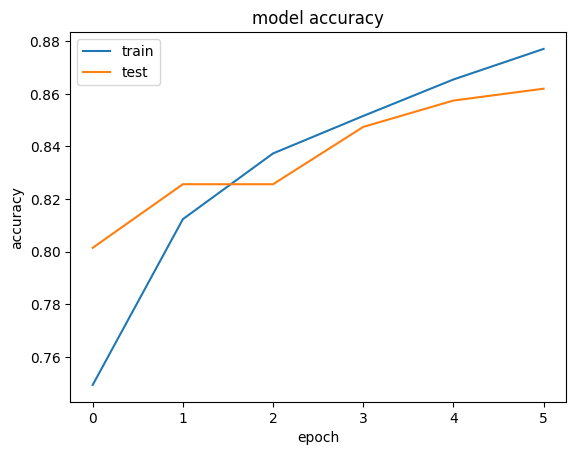

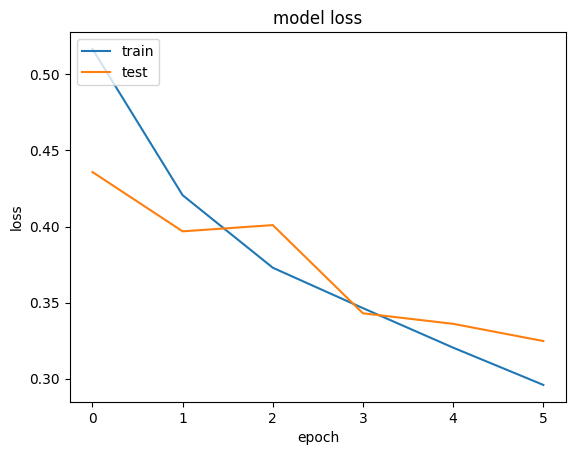

In [41]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history.history['acc'])
plt.plot(lstm_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [42]:
# Saving the model file for possible use later
lstm_model.save(f"../data/processed/lstm_model_acc_{round(score[1], 3)}.keras")

# Making Predictions on Live IMDb data

In [43]:
# Load previously trained LSTM Model

from keras.models import load_model

model_path = '../data/processed/lstm_model_acc_0.867.keras'
pretrained_lstm_model = load_model(model_path)

# # summarize model.
pretrained_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     9,192,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,544,833 (36.41 MB)

 Trainable params: 117,377 (458.50 KB)

 Non-trainable params: 9,192,700 (35.07 MB)

 Optimizer params: 234,756 (917.02 KB)

In [44]:
# Load sample IMDb reviews csv
sample_reviews = pd.read_csv("../data/raw/dataset-unseen.csv")

sample_reviews.head(6)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive


In [46]:
# Preprocess review text with earlier defined preprocess_text function

unseen_reviews = sample_reviews['review']

unseen_processed = []
for review in unseen_reviews:
  review = preprocess_text(review)
  unseen_processed.append(review)

In [47]:
# Tokenising instance with earlier trained tokeniser
unseen_tokenized = word_tokenizer.texts_to_sequences(unseen_processed)

# Pooling instance to have maxlength of 100 tokens
unseen_padded = pad_sequences(unseen_tokenized, padding='post', maxlen=maxlen)

In [48]:
# Passing tokenised instance to the LSTM model for predictions
unseen_sentiments = lstm_model.predict(unseen_padded)

unseen_sentiments

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[6.43428206e-01],
       [9.55203950e-01],
       [9.74652112e-01],
       [7.07991496e-02],
       [9.67695832e-01],
       [9.81057584e-01],
       [7.52633750e-01],
       [1.68978814e-02],
       [1.27082262e-02],
       [9.73678768e-01],
       [3.10084015e-01],
       [2.25121304e-01],
       [2.20562652e-01],
       [1.98686883e-01],
       [9.81936991e-01],
       [2.38090605e-02],
       [2.05314100e-01],
       [8.60920292e-04],
       [6.83685005e-01],
       [8.59534089e-03],
       [3.54796112e-01],
       [3.58247035e-03],
       [9.29222584e-01],
       [8.80123489e-03],
       [2.34175399e-02],
       [9.44451749e-01],
       [9.52835917e-01],
       [7.00110197e-02],
       [3.50453444e-02],
       [6.00893855e-01],
       [6.08970188e-02],
       [9.53988612e-01],
       [1.53322555e-02],
       [8.17897201e-01],
       [8.48434772e-03],
       [2.57196072e-02],
       [5.27746556e-03],
       [2.11423248e-01],
       [5.44988394e-01],
       [1.40710816e-01],


In [51]:
# Writing model output file 

sample_reviews['Predicted Sentiments'] = np.round(unseen_sentiments*10, 1)

# df_prediction_sentiments = pd.DataFrame(sample_reviews['Predicted Sentiments'], columns = ['Predicted Sentiments'])
# df_movie                 = pd.DataFrame(sample_reviews['Movie'], columns = ['Movie'])
# df_review_text           = pd.DataFrame(sample_reviews['Review Text'], columns = ['Review Text'])
# df_imdb_rating           = pd.DataFrame(sample_reviews['IMDb Rating'], columns = ['IMDb Rating'])

df_prediction_sentiments = pd.DataFrame(sample_reviews['Predicted Sentiments'], columns = ['Predicted Sentiments'])
df_review_text           = pd.DataFrame(sample_reviews['review'], columns = ['review'])


dfx = pd.concat([df_review_text, df_prediction_sentiments], axis=1)

dfx.to_csv("../data/processed/prediction-unseen.csv", sep=',', encoding='UTF-8')

dfx.head(6)

,review,Predicted Sentiments
0,One of the other reviewers has mentioned that ...,6.4
1,A wonderful little production. <br /><br />The...,9.6
2,I thought this was a wonderful way to spend ti...,9.7
3,Basically there's a family where a little boy ...,0.7
4,"Petter Mattei's ""Love in the Time of Money"" is...",9.7
5,"Probably my all-time favorite movie, a story o...",9.8
